In [1]:
import os

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline
import seaborn as sns

from tensorflow.keras import models, layers
import tensorflow as tf
import random

from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (confusion_matrix
, classification_report
, precision_score
, recall_score
, f1_score
, precision_recall_curve
, average_precision_score
, auc)

from tqdm import tqdm
from itertools import product

import shap

import warnings
warnings.filterwarnings('ignore')

In [3]:
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

In [4]:
print(train_df.shape, val_df.shape, test_df.shape)

(113842, 31) (28462, 32) (142503, 31)


In [5]:
display(train_df.head())
display(val_df.head())
display(test_df.head())

,ID,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30
0,3,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,-0.994972
1,4,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,-0.994972
2,6,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,-0.256131,-0.994960
3,8,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,0.262698,-0.994901
4,9,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,0.994900,-0.994901


,ID,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,V29,V30,Class
0,10,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,-0.255991,-0.994878,0
1,22,0.962496,0.328461,-0.171479,2.109204,1.129566,1.696038,0.107712,0.521502,-1.191311,...,0.402492,-0.048508,-1.371866,0.390814,0.199964,0.016371,-0.014605,0.168937,-0.994784,0
2,63,1.145524,0.575068,0.194008,2.598192,-0.092210,-1.044430,0.531588,-0.241888,-0.896287,...,-0.119703,-0.076510,0.691320,0.633984,0.048741,-0.053192,0.016251,0.169496,-0.994502,0
3,69,0.927060,-0.323684,0.387585,0.544474,0.246787,1.650358,-0.427576,0.615371,0.226278,...,0.079359,0.096632,-0.992569,0.085096,0.377447,0.036096,-0.005960,0.331307,-0.994467,0
4,83,-3.005237,2.600138,1.483691,-2.418473,0.306326,-0.824575,2.065426,-1.829347,4.009259,...,-0.181268,-0.163747,0.515821,0.136318,0.460054,-0.251259,-1.105751,-0.287012,-0.994373,0


,ID,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30
0,AAAA0x1,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,-0.994983
1,AAAA0x2,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,-0.994983
2,AAAA0x5,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,-0.994960
3,AAAA0x7,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,-0.237686,-0.994937
4,AAAA0xc,0.384978,0.616109,-0.874300,-0.094019,2.924584,3.317027,0.470455,0.538247,-0.558895,...,0.049924,0.238422,0.009130,0.996710,-0.767315,-0.492208,0.042472,-0.054337,-0.167819,-0.994866


In [6]:
train_df.columns

Index(['ID', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30'],
      dtype='object')

In [7]:
val_df.columns

Index(['ID', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30',
       'Class'],
      dtype='object')

In [8]:
print(train_df.dtypes)
print(val_df.dtypes)
print(test_df.dtypes)

ID       int64
V1     float64
V2     float64
V3     float64
V4     float64
V5     float64
V6     float64
V7     float64
V8     float64
V9     float64
V10    float64
V11    float64
V12    float64
V13    float64
V14    float64
V15    float64
V16    float64
V17    float64
V18    float64
V19    float64
V20    float64
V21    float64
V22    float64
V23    float64
V24    float64
V25    float64
V26    float64
V27    float64
V28    float64
V29    float64
V30    float64
dtype: object
ID         int64
V1       float64
V2       float64
V3       float64
V4       float64
V5       float64
V6       float64
V7       float64
V8       float64
V9       float64
V10      float64
V11      float64
V12      float64
V13      float64
V14      float64
V15      float64
V16      float64
V17      float64
V18      float64
V19      float64
V20      float64
V21      float64
V22      float64
V23      float64
V24      float64
V25      float64
V26      float64
V27      float64
V28      float64
V29      float64
V30      fl

In [9]:
# 결측치 확인
def check_missing(df, name):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending = False)

    print(f"[{name}]")
    if len(missing) == 0:
        print("결측치 없음")
    else:
        print(missing)

In [10]:
check_missing(train_df, "train")
check_missing(val_df, "val")
check_missing(test_df, "test")

[train]
결측치 없음
[val]
결측치 없음
[test]
결측치 없음


In [11]:
class_dist = val_df["Class"].value_counts().sort_index()
class_ratio = val_df["Class"].value_counts(normalize = True).sort_index() * 100

In [12]:
summary_df = pd.DataFrame({"Target" : class_dist.index
                           , "Count" : class_dist.values
                           , "Percent (%)" : class_ratio.values.round(4)
                          })
summary_df

,Target,Count,Percent (%)
0,0,28432,99.8946
1,1,30,0.1054


In [13]:
sns.set_theme(style = "whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

Text(0.5, 1.02, 'Class Imbalance Analysis: 0.11% Fraud in Validation Set')

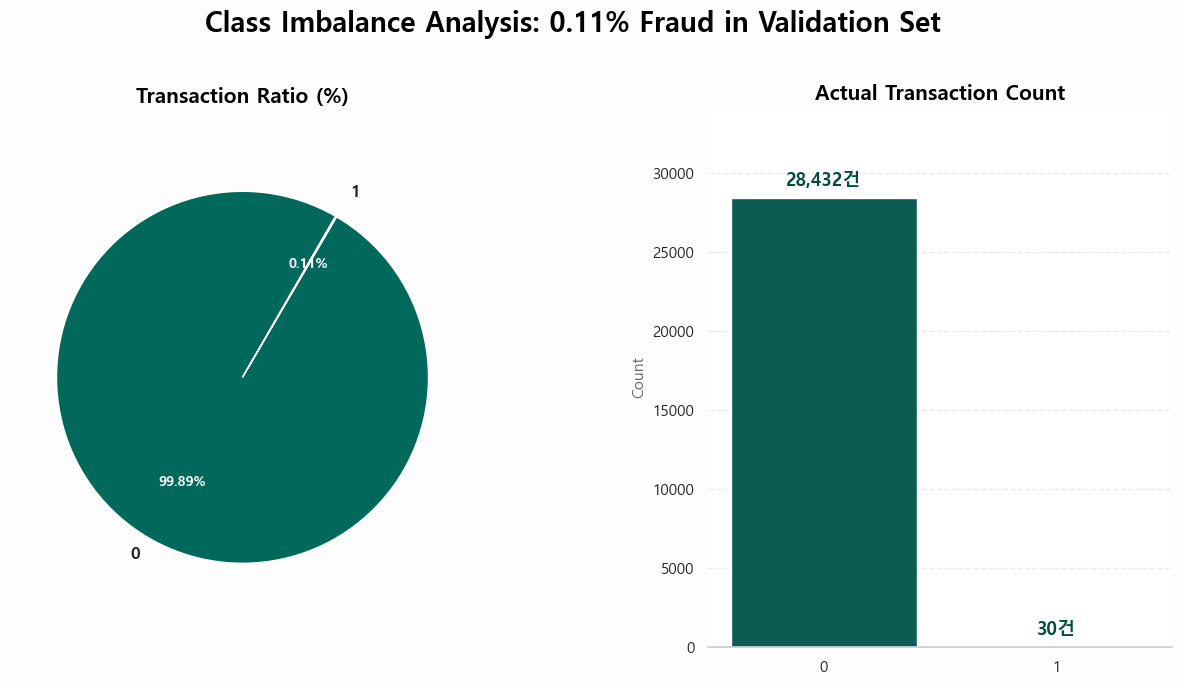

In [14]:
colors = ['#00695C', '#FF6D00']

fig, ax = plt.subplots(1, 2, figsize = (15, 7), facecolor = "#FDFDFD")
plt.subplots_adjust(wspace = 0.5)

# 1. pie chart
explode = [0, 0.05]

wedges, texts, autotexts = ax[0].pie(
    summary_df["Count"]
    , labels = summary_df["Target"]
    , autopct = "%1.2f%%"
    , startangle = 60
    , colors = colors
    , explode = explode
    , pctdistance = 0.65
    , labeldistance = 1.1
    , textprops = {"fontsize" : 12, "fontweight" : "bold"}
)

for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)

ax[0].set_title("Transaction Ratio (%)", fontsize = 15, pad = 30, fontweight = "bold", color = "black")

sns.barplot(x = "Target", y = "Count", data = summary_df, ax = ax[1], palette = colors, hue = "Target", legend = False)

for p in ax[1].patches:
    ax[1].annotate(f"{int(p.get_height()):,}건"
                   , (p.get_x() + p.get_width() / 2., p.get_height())
                   , ha = "center", va = "center"
                   , xytext = (0, 12)
                   , textcoords = "offset points"
                   , fontsize = 13
                   , fontweight = "bold"
                   , color = "#004D40"
                  )

ax[1].set_title("Actual Transaction Count", fontsize = 15, fontweight = 'bold', color = 'black')
ax[1].set_ylim(0, summary_df["Count"].max() * 1.2)
ax[1].set_xlabel("")
ax[1].set_ylabel("Count", color = "#666666", fontsize = 11)
ax[1].tick_params(axis = "both", which = "major", labelsize = 11)

sns.despine(ax = ax[1], left = True)
ax[1].grid(axis = 'y', linestyle = "--", alpha = 0.4)

plt.suptitle("Class Imbalance Analysis: 0.11% Fraud in Validation Set"
             , fontsize = 20, fontweight = "bold", color = "black", y = 1.02)

In [15]:
# contamination 비율 계산 - 실제 비율 참고값으로만 확인
val_normal = (val_df["Class"] == 0).sum()
val_fraud = (val_df["Class"] == 1).sum()

val_contamination = val_fraud / len(val_df)

print("정상 거래 수:", val_normal)
print("사기 거래 수:", val_fraud)
print("사기 비율(contamination):", round(val_contamination, 6))

정상 거래 수: 28432
사기 거래 수: 30
사기 비율(contamination): 0.001054


# 01. EDA

## Question
**이상거래 데이터는 어떤 구조와 분포를 가지고 있는가?**

## Objective
정상·사기 거래의 분포와 특성을 확인하고,
이상치 탐지 모델을 적용할 수 있는 데이터 구조인지 검토한다.

In [16]:
# fraud / normal 분리
fraud_df = val_df[val_df["Class"] == 1]
normal_df = val_df[val_df["Class"] == 0]

print("fraud : ", fraud_df.shape)
print("normal : ", normal_df.shape)

fraud :  (30, 32)
normal :  (28432, 32)


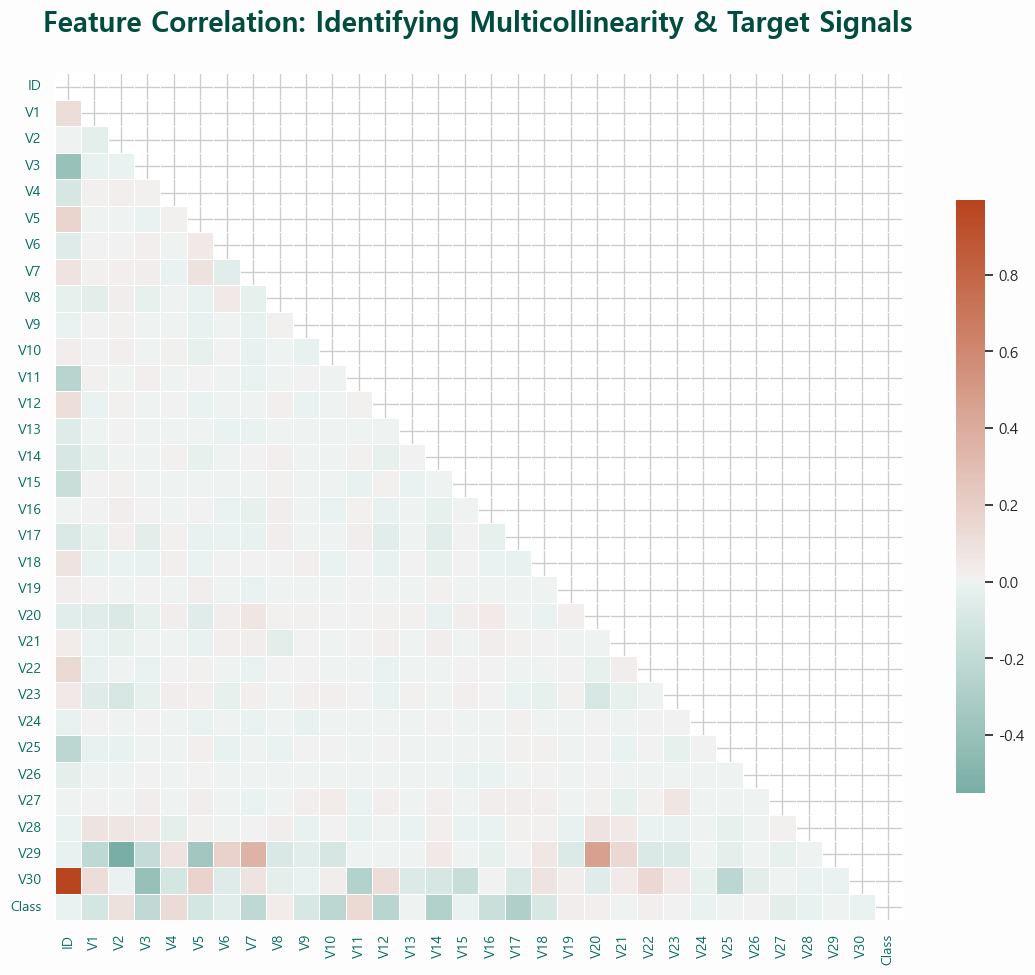

In [17]:
# 변수별 상관계수 heatmap 확인
corr = val_df.corr()

plt.figure(figsize = (14, 11), facecolor = "#FDFDFD")

cmap = sns.diverging_palette(170, 20, s = 90, l = 45, as_cmap = True)

mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr
            , mask = mask
            , cmap = cmap
            , center = 0
            , square = True
            , linewidths = .7
            , cbar_kws = {"shrink" : .7}
            , annot = False)

plt.title("Feature Correlation: Identifying Multicollinearity & Target Signals"
          , fontsize = 20, fontweight = "bold", color = "#004D40", pad = 30)
plt.xticks(color = "#00695C", fontsize = 10)
plt.yticks(color = "#00695C", fontsize = 10)

plt.show()

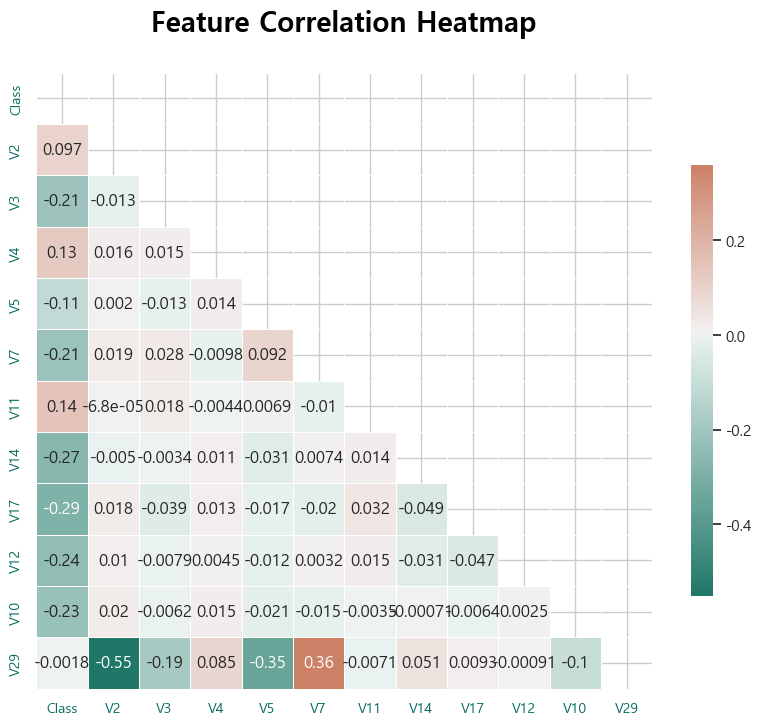

In [18]:
corr_cols = ["Class", "V2", "V3", "V4", "V5", "V7", "V11", "V14", "V17", "V12", "V10", "V29"]
corr_df = val_df[corr_cols].corr()

plt.figure(figsize = (10, 8))

cmap = sns.diverging_palette(170, 20, s = 90, l = 45, as_cmap = True)

mask = np.triu(np.ones_like(corr_df, dtype = bool))

sns.heatmap(corr_df
            , mask = mask
            , cmap = cmap
            , center = 0
            , square = True
            , linewidths = .7
            , cbar_kws = {"shrink" : .7}
            , annot = True)

plt.title("Feature Correlation Heatmap", fontsize = 20, fontweight = "bold", color = "black", pad = 30)
plt.xticks(color = "#00695C", fontsize = 10)
plt.yticks(color = "#00695C", fontsize = 10)

plt.show()

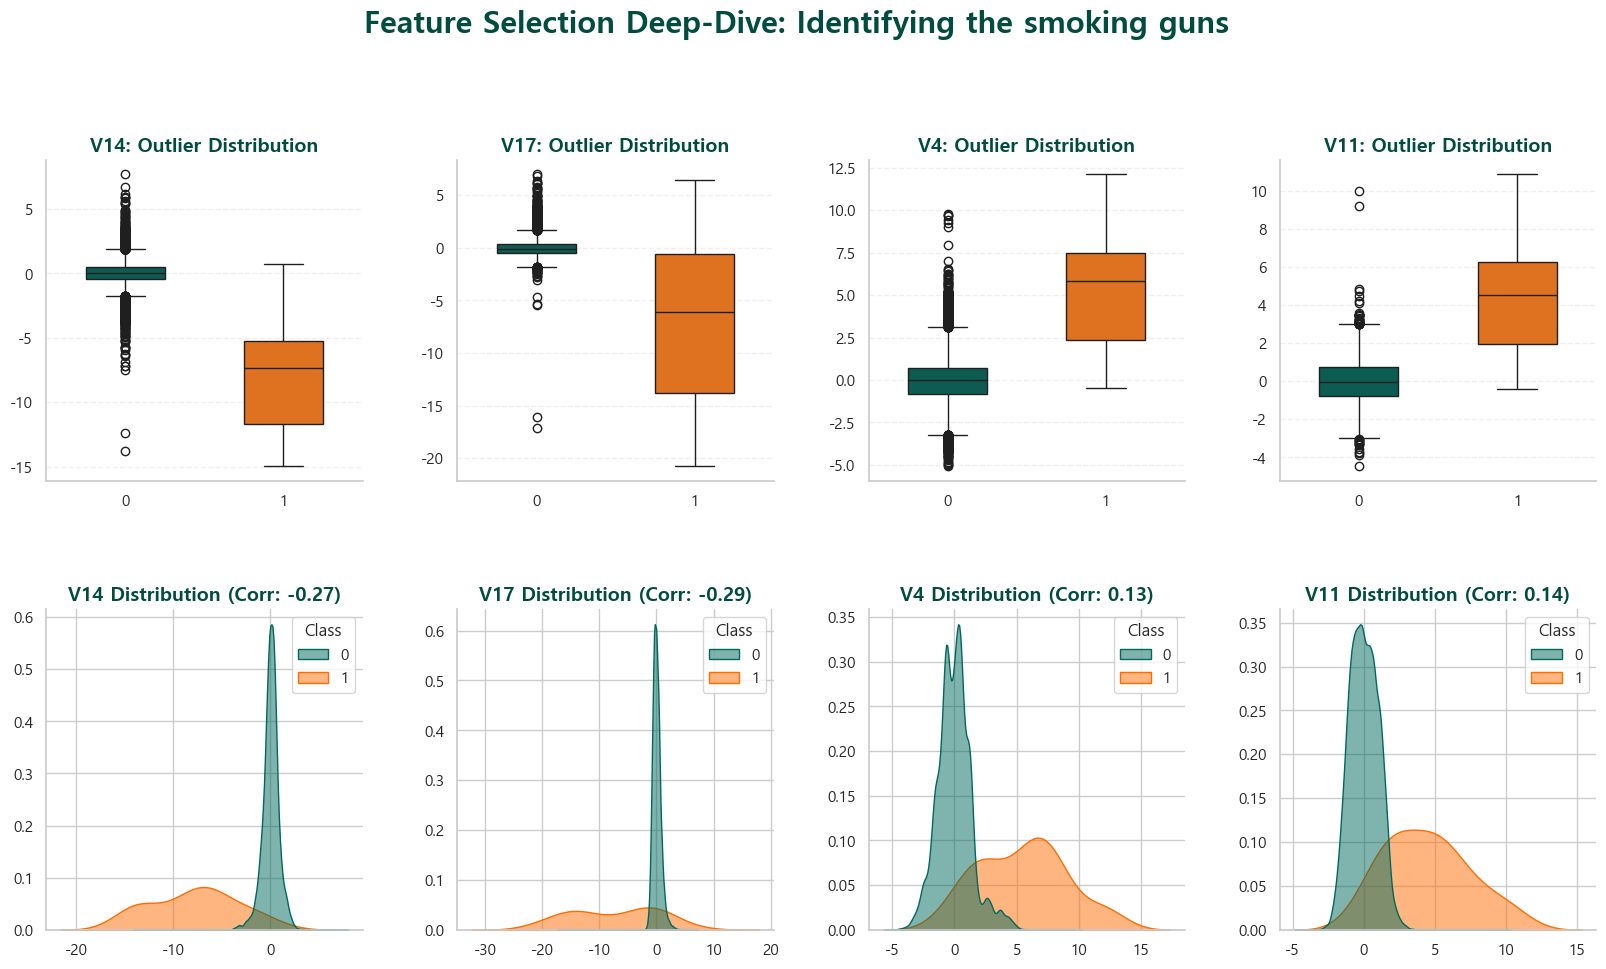

In [19]:
# 분석 결과 상관계수가 큰 4개 변수 선택
smoking_gun_features = ["V14", "V17", "V4", "V11"]
colors = ['#00695C', '#FF6D00']

fig, axes = plt.subplots(2, 4, figsize = (20, 10))
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)

for i, col in enumerate(smoking_gun_features):
    # 상단 boxplot - 중앙값 및 이상치 확인
    sns.boxplot(x = "Class", y = col, data = val_df, ax = axes[0, i]
                , palette = colors, hue = "Class", legend = False, width = 0.5)
    axes[0, i].set_title(f"{col}: Outlier Distribution", fontsize = 14, fontweight = "bold", color = "#004D40")
    axes[0, i].set_xlabel("")
    axes[0, i].set_ylabel("")
    sns.despine(ax = axes[0, i])
    axes[0, i].grid(axis = "y", linestyle = "--", alpha = 0.3)

    # 하단 Kde plot - 클래스별 밀도 차이 확인
    sns.kdeplot(data = val_df, x = col, hue = "Class", fill = True, ax = axes[1, i]
                , palette = colors, common_norm = False, alpha = 0.5)
    axes[1, i].set_title(f"{col} Distribution (Corr: {val_df.corr()['Class'][col]:.2f})", fontsize=14, fontweight='bold', color='#004D40')
    axes[1, i].set_xlabel("")
    axes[1, i].set_ylabel("")
    sns.despine(ax = axes[1, i])

plt.suptitle("Feature Selection Deep-Dive: Identifying the smoking guns"
             , fontsize = 22, fontweight = "bold", color = "#004D40", y = 1.03)
plt.show()

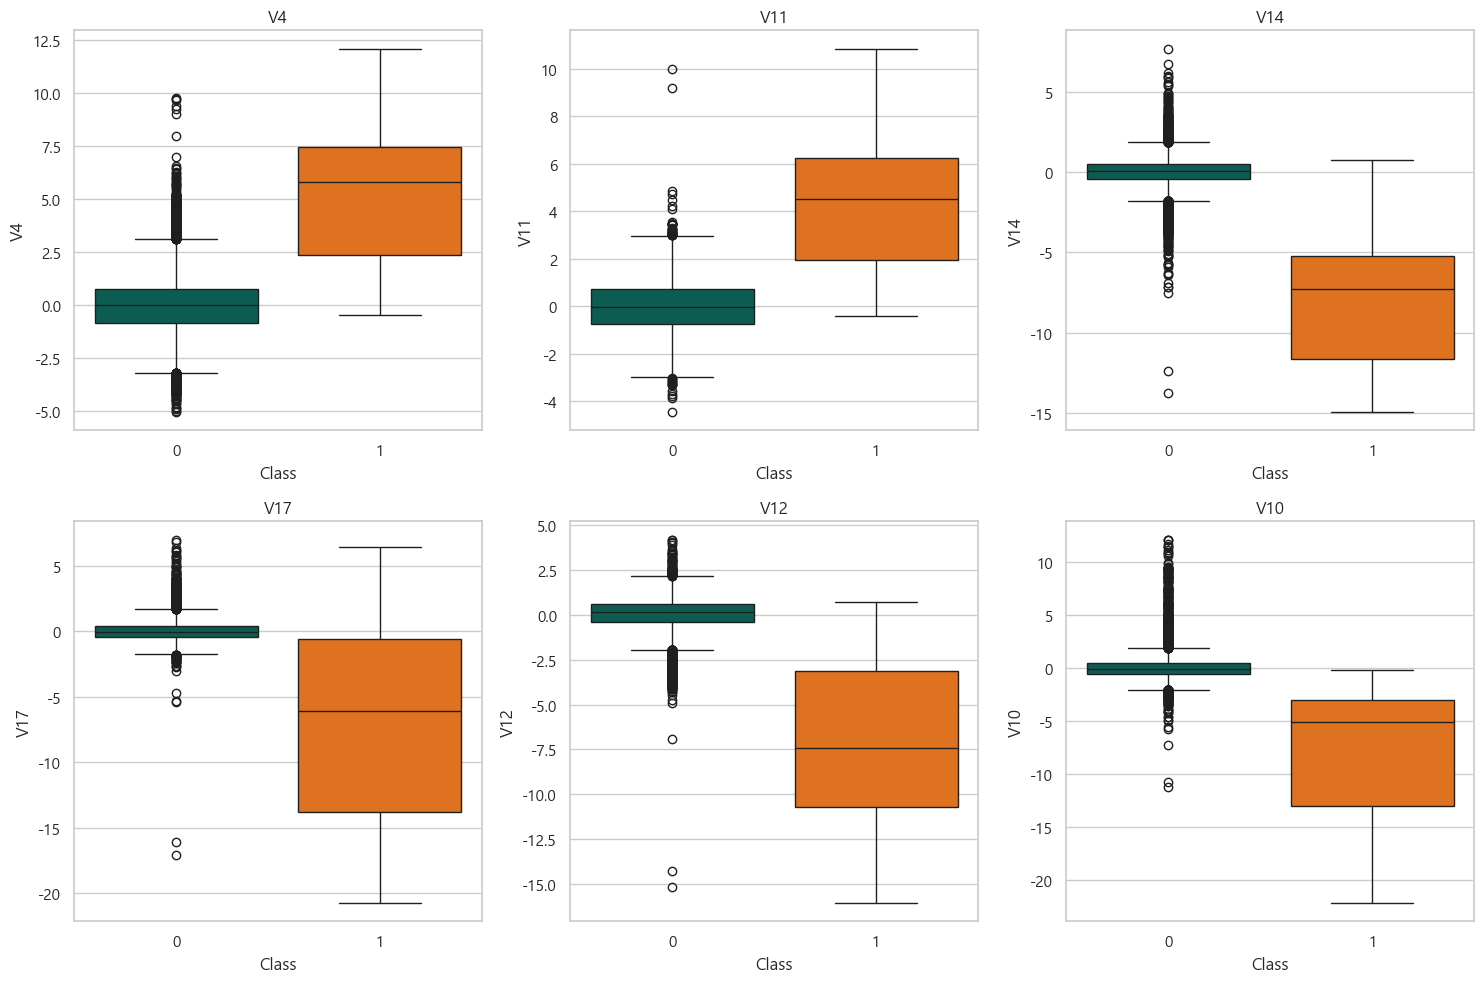

In [20]:
# 사기데이터는 이상치가 핵심이므로 - 이상치 탐지 / 클래스별 분포 비교 / 중앙값 차이 확인
# 그 외 feature
cols = ["V4", "V11", "V14", "V17", "V12", "V10"]

colors = ['#00695C', '#FF6D00']

plt.figure(figsize = (15, 10))
for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x = "Class" , y = col, data = val_df, palette = colors, hue = "Class", legend = False)
    plt.title(col)
plt.tight_layout()
plt.show()

In [23]:
def get_outlier(df = None, column = None, weight = None):
    fraud = df[df["Class"] == 1][column]

    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)

    iqr = quantile_75 - quantile_25
    lowest_val = quantile_25 - iqr * weight
    highest_val = quantile_75 + iqr * weight

    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index